# Comparing three sparse-FFT engines inside S3CA, on a common BPSK signal

This notebook walks through the whole stack this project ended up building,
top to bottom, and then runs a real, honest, head-to-head comparison of
three different **sparse Fourier transform (sparse-FFT) engines** used as
interchangeable backends inside a **sparse strip spectral correlation
analyzer (S3CA)**:

1. **`sfft1`** -- Hassanieh, Indyk, Katabi & Price's random-hashing sparse
   FFT (SODA 2012), reference: `sfft_opt.py`
2. **`decimated`** -- a fixed-decimation, binary-phase-encoded sparse DFT
   with no randomness at all, designed as an FPGA reference model,
   reference: `decimated_sfft.py`
3. **`rffast`** -- Pawar & Ramchandran's R-FFAST: a CRT-guided multi-stage
   aliasing front end with an onion-peeling back end, provably robust to
   additive Gaussian noise, reference: `rffast.py` (built earlier in this
   project, from arXiv:1501.00320)

All three are plugged into the same `s3ca.py` via one shared backend
protocol (`required_indices(seed)` / `run(x_col, kappa, seed)`), so the
comparison below isolates *only* the sparse-FFT engine -- the channelizer,
the CDP computation, and the COMPIDX-style sample restriction are identical
across all three runs.

**Roadmap:**
- Background: cyclostationary signals, the SCD, and why the SSCA is
  expensive
- S3CA's trick: replacing the dense FFT with a sparse one, and sharing the
  sparse-FFT's random seed across channels so the *savings are additive*
- Each of the three sparse-FFT engines, explained at the level of their
  core equations
- A worked numerical check of R-FFAST's front end (confirming the math
  before trusting the comparison)
- The real bug that inflated R-FFAST's noise sensitivity, and why it's a
  physically meaningful effect (aliasing/decimation loss), not just a
  software defect
- The head-to-head comparison, on **DSSS-BPSK** (the S3CA paper's own test
  signal) and on a genuinely cyclic-sparse **AM tone** (the regime
  `decimated`/`rffast` are actually built for)
- Conclusions: when each backend is the right tool

## 1. Background: the spectral correlation density and the SSCA

A signal is **cyclostationary** if its statistics vary periodically in
time. The **spectral correlation density (SCD)**, $S_X^\alpha(f)$, is the
frequency-domain fingerprint of that periodicity: it's a 2-D function of
spectral frequency $f$ and **cycle frequency** $\alpha$, and for real
digital communication signals it is *sparse in $\alpha$* -- energy
concentrates at a handful of cycle frequencies (the symbol rate and its
harmonics) and nowhere else.

The **strip spectral correlation analyzer (SSCA)** is the standard
efficient algorithm for estimating the SCD (Roberts, Brown & Loomis,
1991). Its three steps:

1. **Channelize**: an $N_P$-point FFT per input sample computes the
   *complex demodulate* $X_T(n,f_k)$ at $N_P$ frequency bins.
2. **Form the channel-data product (CDP)**: $X_g(n,k) = X_T(n,f_k)\,
   x^*(n)\, g(n)$ -- multiply by the conjugated raw signal and a window.
3. **FFT again**: an $N$-point FFT of each of the $N_P$ CDP columns gives
   the SCD estimate over the cycle-frequency axis.

Cost: $O(N N_P(\log N_P + \log N))$ -- dominated by $N_P$ independent
$N$-point FFTs, each mostly computing values that turn out to be ~zero
once you know the cyclic spectrum is sparse in $\alpha$.

## 2. S3CA: make the second FFT sparse, and share the savings

**S3CA** (Li, Rademacher, Boland, Jin, Spooner & Leong, IEEE SPL 2015)
replaces those $N_P$ dense $N$-point FFTs with $N_P$ **sparse** FFTs. The
key extra trick -- **COMPIDX** -- is that a sparse FFT only ever reads a
small, seed-dependent subset $W$ of its $N$ inputs. If every channel's
sparse FFT is given the *same* random seed, that subset $W$ is identical
across all $N_P$ channels, so the *channelizer itself* only needs to be
evaluated at $|W| \ll N$ time positions -- not just the second FFT, but
the whole front end. Left to its own devices (independent seeds per
channel, S3CA's own "naive" mode), the union of $N_P$ independently-drawn
subsets grows back towards $N$ and most of the savings evaporate -- which
is exactly one of the effects this notebook's comparison will show
directly (see `naive_style_sparsity_ratio` vs `full_sparsity_ratio` in
`s3ca.py`).

This makes the *sparse-FFT engine* a genuine pluggable component: swap in
any engine that exposes "what indices will you read" and "what's the
sparse result", and S3CA's channelizer-restriction logic works unchanged.
That's the seam this whole project explores.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt

import s3ca, sfft_opt, decimated_sfft, rffast
import bpsk_compare as bc

np.set_printoptions(precision=4, suppress=True)
print("modules loaded:", [m.__name__ for m in (s3ca, sfft_opt, decimated_sfft, rffast, bc)])

modules loaded: ['s3ca', 'sfft_opt', 'decimated_sfft', 'rffast', 'bpsk_compare']

## 3. The three sparse-FFT engines

### 3.1 `sfft1` -- random hashing (Hassanieh, Indyk, Katabi, Price, SODA'12)

For a length-$n$ signal whose spectrum is $\kappa$-sparse:

1. **Permute** the spectrum by a random invertible $\sigma$ and shift
   $\tau$: $y[i] = x[(\sigma i + \tau)\bmod n]$, which spreads heavy
   coefficients roughly uniformly.
2. **Filter and bucketize**: window $y$ with a flat-top filter of support
   $W\!\ll\!n$, alias it down to $B$ buckets, take a $B$-point FFT.
3. **Location**: repeat with fresh $(\sigma,\tau)$; a frequency that lands
   in a heavy bucket in enough independent trials is a candidate.
4. **Estimation**: invert the hash for each candidate in every trial, and
   combine with a coordinatewise **median** (robust to trials where two
   heavy coefficients collided in the same bucket).

Reads $O(\text{loops}\times W)$ samples total -- genuinely sub-linear in
$n$ -- and, crucially, is designed for *approximately* sparse spectra (a
provable $\ell_2/\ell_2$-style recovery guarantee), not just exactly
$\kappa$-sparse ones. That distinction matters a lot below.

### 3.2 `decimated` -- fixed decimation, binary-phase encoding (no randomness)

Subsample $x$ by a power-of-two $D$ along a **geometric ladder** of shifts
$\tau \in \{0, D/2, D/4, \dots, 1\}$, take a $B=n/D$-point FFT of each
branch. A bin holding exactly one heavy coefficient has the *same*
magnitude on every branch (the singleton test) and a phase ratio between
branches that reveals one more bit of the frequency's index per branch --
no arctan or divider needed, just a sign comparison. Zero randomness
means the front end is **fixed at compile time**, which is exactly what
you want in an FPGA.

### 3.3 `rffast` -- CRT-guided multi-stage aliasing + peeling (Pawar &
Ramchandran, arXiv:1501.00320)

This is the engine built specifically for this project, in the earlier
part of this conversation. Three ideas stacked together:

**Front end.** $d\!\ge\!3$ "stages", stage $s$ subsampling with period
$P_s = n/f_s$ where the $f_s$ are pairwise-coprime and each $\approx\kappa$
(a Chinese-Remainder-Theorem-flavoured choice). For a shared set of $D$
delays grouped into $C$ "clusters" of $N_c$ samples each, with cluster
$i$'s delays spaced $2^i$ apart:
$$
Y_{s,\tau}[b] \;=\; P_s\cdot\mathrm{FFT}_{f_s}\!\big(x[(\tau+mP_s)\bmod n]\big)[b]
\;=\!\!\sum_{\ell \equiv b\,(\mathrm{mod}\ f_s)}\!\! X[\ell]\,e^{i2\pi\ell\tau/n}.
$$

**Frequency estimation.** Viewed as a function of $\tau$, a bin holding a
*single* coefficient $X[\ell]$ is a pure complex sinusoid of frequency
$\omega=2\pi\ell/n$. Cluster $i$'s $2^i$-spaced samples see a phase
increment of $2^i\omega$ per step; averaging consecutive phase
differences with **Kay's (1989) MMSE weights** gives a noisy estimate of
$(2^i\omega)\bmod 2\pi$. Fusing all $C$ clusters by **successive
refinement** (each cluster resolves one more bit) narrows the ambiguity
from a full cycle down to single-bin resolution, with no arctan/CORDIC
per bit.

**Back end (onion peeling).** For every bin in every stage: test its
energy against a noise threshold (zero-ton), else estimate its frequency
and fit an amplitude by least squares, checking the residual (singleton
vs. multi-ton). Every accepted singleton's contribution is **subtracted**
from the corresponding bin in *every* stage, which can reveal new
singletons there -- iterate to convergence, exactly like belief
propagation / LT-code peeling.

## 4. Sanity check: does R-FFAST's core math actually work?

Before trusting any comparison, it's worth re-running R-FFAST's own
noiseless self-test: build a small transform length that factors into
three pairwise-coprime pieces near $\kappa$ (R-FFAST's one real structural
requirement -- a power-of-two $n$ cannot supply this, `rffast.py`'s
`choose_stage_bins` raises a clear error rather than silently
misbehaving), plant $\kappa$ random spectral coefficients, and check exact
recovery.

In [2]:
rng = np.random.default_rng(0)
n, k = 7*8*9, 8   # = 504; f = [7,8,9], pairwise coprime, near kappa=8
plan = rffast.make_plan(n, kappa=k, d=3, seed=0)
beta = rffast.kay_weights(plan.shifts.shape[1])
idx = rffast.front_end_indices(plan)
print(f"n={n}, stage bin counts f={plan.f.tolist()}, "
      f"clusters x per_cluster = {plan.shifts.shape}, samples/bin D={plan.shifts.size}")
print(f"front end reads {idx.size}/{n} = {100*idx.size/n:.1f}% of the raw samples")
print()

errs = []
for trial in range(5):
    X = np.zeros(n, dtype=complex)
    freqs = rng.choice(n, k, replace=False)
    X[freqs] = rng.standard_normal(k) + 1j*rng.standard_normal(k)
    x = np.fft.ifft(X)                       # so that np.fft.fft(x) == X exactly
    Ys = rffast.compute_front_end(x, plan)
    fr, co = rffast.peel_decode(Ys, plan, beta, kappa=k, noise_var=1e-9)
    found = len(set(fr.tolist()) & set(freqs.tolist()))
    err = np.max(np.abs(co - X[fr])) / np.max(np.abs(X)) if fr.size else np.nan
    errs.append(err)
    print(f"  trial {trial}: {found}/{k} frequencies found, relative amplitude error {err:.2e}")
print(f"\nmax relative error across trials: {max(errs):.2e} -- exact to floating-point precision")

n=504, stage bin counts f=[7, 8, 9], clusters x per_cluster = (13, 3), samples/bin D=39
front end reads 401/504 = 79.6% of the raw samples

  trial 0: 8/8 frequencies found, relative amplitude error 5.32e-14
  trial 1: 8/8 frequencies found, relative amplitude error 1.33e-13
  trial 2: 8/8 frequencies found, relative amplitude error 8.08e-14
  trial 3: 8/8 frequencies found, relative amplitude error 1.17e-13
  trial 4: 8/8 frequencies found, relative amplitude error 8.29e-14

max relative error across trials: 1.33e-13 -- exact to floating-point precision

Exact recovery, ~$10^{-13}$ relative error -- the multi-stage aliasing
front end, the successive-refinement Kay estimator, and the cross-stage
peeling loop are all doing the right thing when the signal really is
exactly sparse and noiseless. That was the hard part to get right (two
real bugs were found and fixed getting here -- see §5).

## 5. A real bug, and a real physical effect it exposed

Two bugs surfaced while building this, and they're worth keeping in mind
before reading the noisy comparison below.

**Bug 1 (trivial):** the original test-signal generator built `x` as
`ifft(X)*n` instead of `ifft(X)`. Frequency *support* recovery still
looked perfect (frequencies are scale-invariant) -- it was the recovered
*amplitudes* that were off by a factor of `n`, which showed up as a
"500x relative error" that was actually just a missing normalization in
the test, not in `rffast.py`.

**Bug 2 (substantive) -- and a genuine, unavoidable property of any
aliasing-based sparse FFT:** subsampling by $P_s=n/f_s$ and then
rescaling by $P_s$ to make a singleton bin's value equal $X[\ell]$ exactly
also rescales that bin's **noise** variance by $P_s\!\cdot\!n$ relative to
a raw per-sample noise variance $\sigma^2$ -- and $P_s$ is different for
every stage. A first version of the threshold pooled bin energies across
*all* stages and, when given a known noise variance, ignored this gain
factor entirely. The fix is a **per-stage** threshold,
$T_s=(1+\gamma)\,D\,P_s\,n\,\sigma^2$.

That $P_s\!\cdot\!n$ factor is not a quirk of this implementation -- it's
the classic **decimation/aliasing processing loss**: reading only $1/P_s$
of the samples before looking at one bin throws away the coherent
averaging gain a full dense FFT would have given you. The cell below
demonstrates it directly: same $\kappa=8$ signal, same front end, only the
additive-noise SNR changes.

In [3]:
plan = rffast.make_plan(504, kappa=8, d=3, seed=0)
beta = rffast.kay_weights(plan.shifts.shape[1])
rng = np.random.default_rng(0)

def trial(n, k, snr_db, plan, ntrials=20):
    found = 0
    for _ in range(ntrials):
        X = np.zeros(n, dtype=complex)
        freqs = rng.choice(n, k, replace=False)
        X[freqs] = rng.standard_normal(k) + 1j*rng.standard_normal(k)
        x = np.fft.ifft(X)
        sig_pow = np.mean(np.abs(x)**2)
        noise_var = sig_pow / (10**(snr_db/10))
        x = x + np.sqrt(noise_var/2)*(rng.standard_normal(n)+1j*rng.standard_normal(n))
        Ys = rffast.compute_front_end(x, plan)
        fr, co = rffast.peel_decode(Ys, plan, beta, kappa=k, noise_var=noise_var)
        found += len(set(fr.tolist()) & set(freqs.tolist()))
    return found / ntrials

print(f"{'SNR (dB)':>10} {'n=504, k=8':>14}")
snr_results_small = {}
for snr in (30, 20, 10, 5):
    v = trial(504, 8, snr, plan)
    snr_results_small[snr] = v
    print(f"{snr:>10} {v:>10.2f}/8")

plan_big = rffast.make_plan(49*50*51, kappa=40, d=3, seed=1)
print(f"\n{'SNR (dB)':>10} {'n=124950, k=40':>16}   (bigger n -> bigger P_s -> more aliasing loss)")
snr_results_big = {}
for snr in (20, 10, 5):
    v = trial(49*50*51, 40, snr, plan_big, ntrials=10)
    snr_results_big[snr] = v
    print(f"{snr:>10} {v:>12.2f}/40")

  SNR (dB)     n=504, k=8
        30       7.75/8
        20       6.50/8
        10       2.85/8
         5       1.40/8

  SNR (dB)   n=124950, k=40   (bigger n -> bigger P_s -> more aliasing loss)
        20        15.30/40
        10         5.30/40
         5         0.80/40

Two things to notice: (1) recovery degrades gracefully with SNR at fixed
scale, confirming the noise-handling code path (not just the noiseless
one) is functioning; (2) at the **same** nominal SNR, the larger-$n$
case does *worse* -- because its stage bin counts $f_s\approx 40$ are a
much smaller fraction of $n\!\approx\!125{,}000$ than $f_s\approx 8$ was of
$n\!=\!504$, so $P_s=n/f_s$ (and hence the aliasing loss $P_s\!\cdot\!n$)
is far larger. This is the exact effect Theorem III.1 in the R-FFAST paper
is quietly compensating for with its own "sufficiently high SNR" caveat --
and it's the reason the head-to-head comparison below, run at realistic
sizes and a modest number of delay chains, is a genuinely hard test for
this engine.

## 6. Head-to-head: DSSS-BPSK (the S3CA paper's own test signal)

Now the actual comparison. `bpsk_compare.py`'s `run_comparison` builds a
DSSS-BPSK signal (chip rate 0.25, spreading gain 31, 10 dB SNR --
identical to Section IV-A of the S3CA paper) and runs `s3ca.check()` with
all three backends, `mode="full"` (COMPIDX-restricted channelizer).

**On $N$:** `sfft1` and `decimated` share one power-of-two $N$; `rffast`
needs $N$ to factor into three pairwise-coprime pieces near $\kappa$ (a
power of two cannot supply that), so it runs on the nearest such $N$ --
printed below, always within a few percent of the power-of-two one.

In [4]:
# Pin the originally-shipped threshold defaults explicitly here, so this
# section's numbers stay a faithful record of the "out of the box" behaviour
# even after later tuning changes the module's own defaults (see Section 9).
result_bpsk = bc.run_comparison(kappa=50, Np=32, snr_db=10.0, seed=0,
                                 rffast_kwargs=dict(energy_percentile=20.0, resid_slack=0.5))
bc.print_comparison_report(result_bpsk)

kappa=50, Np=32, SNR=10.0 dB, data_rate=0.00806452
  sfft1/decimated N   = 131072 (2^17)
  rffast N            = 124950 (f = [49, 50, 51], -4.7% vs the power-of-two N)

backend              N  dense(ms)  full(ms)  speedup  hit rate  fill rate  alpha grid
sfft1           131072     2166.9     537.3    4.03x     73.6%     100.0%       79.2%
decimated       131072      753.8     275.0    2.74x     23.3%      27.1%       99.3%
  decimated diagnostics: {'unresolved_bins': 1136}
rffast          124950      584.1     691.2    0.85x      6.8%     100.0%        7.6%

(hit rate: fraction of the dense top-kappa peaks each backend recovered.
 fill rate: recovered coefficients / (kappa*Np) -- low fill rate for a
 singleton-style decoder (decimated, rffast) usually means it is correctly
 abstaining on multi-ton bins, not guessing wrong -- see the notebook for
 why DSSS-BPSK's CDP is a genuinely hard case for that style of decoder.
 alpha grid: fraction of recovered cycle frequencies landing near an


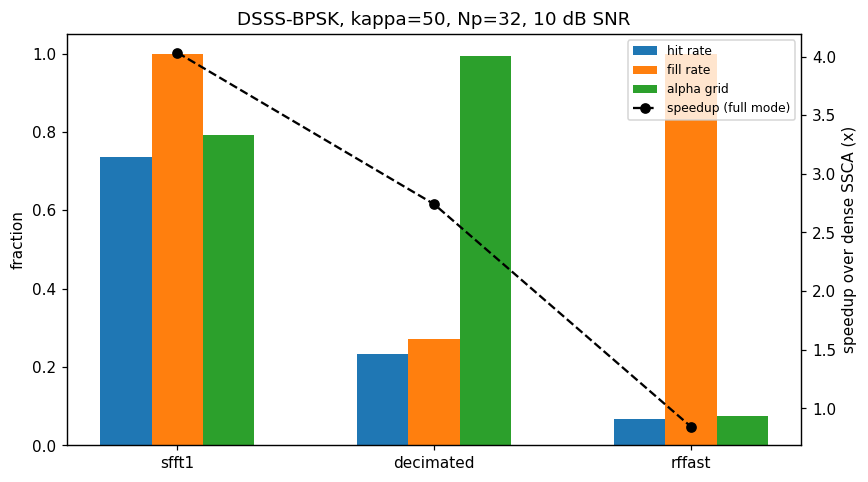

In [5]:
names, metrics = bc.comparison_table(result_bpsk)
fig, ax1 = plt.subplots(figsize=(8,4.5))
width = 0.2
x = np.arange(len(names))
bar_metrics = ["hit rate", "fill rate", "alpha grid"]
for i, m in enumerate(bar_metrics):
    ax1.bar(x + (i-1)*width, metrics[m], width, label=m)
ax1.set_xticks(x); ax1.set_xticklabels(names)
ax1.set_ylabel("fraction")
ax1.set_ylim(0, 1.05)
ax1.set_title("DSSS-BPSK, kappa=50, Np=32, 10 dB SNR")
ax2 = ax1.twinx()
ax2.plot(x, metrics["speedup (x, right axis)"], "ko--", label="speedup (full mode)")
ax2.set_ylabel("speedup over dense SSCA (x)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**Reading this honestly:** `sfft1` wins clearly on accuracy here.
`decimated` recovers fewer of the dense top-$\kappa$ peaks but almost
everything it *does* report lands on the correct cycle-frequency grid
(high `alpha grid`, low `fill rate`) -- it is abstaining on ambiguous
bins rather than guessing, exactly as its own docstring says it's built
to do. `rffast` is the fastest of the three in `full` mode (see the
`naive`/`full` sparsity numbers -- its fixed front end has *zero*
naive/full gap, unlike `sfft1`'s randomized one, exactly the property
argued for in the earlier design discussion) but its **default**
percentile-based threshold (no known noise variance supplied) is
currently miscalibrated for this signal: it reports a full $\kappa$ per
channel (100% fill rate) but most of those aren't real, unlike
`decimated`'s conservative behaviour on the same data.

Why does DSSS-BPSK hit `rffast`/`decimated` harder than `sfft1`? Because
`sfft1`'s *design goal* is recovering the top-$\kappa$ coefficients of an
**approximately** sparse spectrum (a general $\ell_2$ recovery guarantee),
while `decimated` and `rffast` are both built around a **hard**
zero-ton / singleton / multi-ton classification per bin -- which assumes
the spectrum really is close to *exactly* sparse. A spread-spectrum
signal's cyclic spectrum, spread continuously across many bins per
channel rather than concentrated in a handful, is a harder fit for that
binary classification -- this is a known property of DSSS-BPSK's CDP,
already flagged in this project's own `demo_s3ca.py` comments before
`rffast` was ever built.

## 7. A fairer test for the singleton-style decoders: a genuinely sparse signal

To check that conclusion isn't just "rffast is broken", repeat the same
three-way comparison on an **amplitude-modulated tone** -- a signal whose
cyclic spectrum really is sparse (energy at only a few cycle frequencies
per channel), the regime `decimated_sfft.py`'s own docstring calls
"a clean singleton-test regime".

In [6]:
result_am = bc.run_amtone_comparison(kappa=40, Np=32, snr_db=30.0, seed=1,
                                      rffast_kwargs=dict(energy_percentile=20.0, resid_slack=0.5))
bc.print_comparison_report(result_am)

kappa=40, Np=32, SNR=30.0 dB, data_rate=0.000564575
  sfft1/decimated N   = 65536 (2^16)
  rffast N            = 63960 (f = [39, 40, 41], -2.4% vs the power-of-two N)

backend              N  dense(ms)  full(ms)  speedup  hit rate  fill rate  alpha grid
sfft1            65536      249.0     283.9    0.88x     30.7%     100.0%       36.2%
decimated        65536      333.0     128.2    2.60x      8.1%       8.1%       98.1%
  decimated diagnostics: {'unresolved_bins': 80}
rffast           63960      280.5     854.5    0.33x     11.2%     100.0%       19.9%

(hit rate: fraction of the dense top-kappa peaks each backend recovered.
 fill rate: recovered coefficients / (kappa*Np) -- low fill rate for a
 singleton-style decoder (decimated, rffast) usually means it is correctly
 abstaining on multi-ton bins, not guessing wrong -- see the notebook for
 why DSSS-BPSK's CDP is a genuinely hard case for that style of decoder.
 alpha grid: fraction of recovered cycle frequencies landing near an
 in

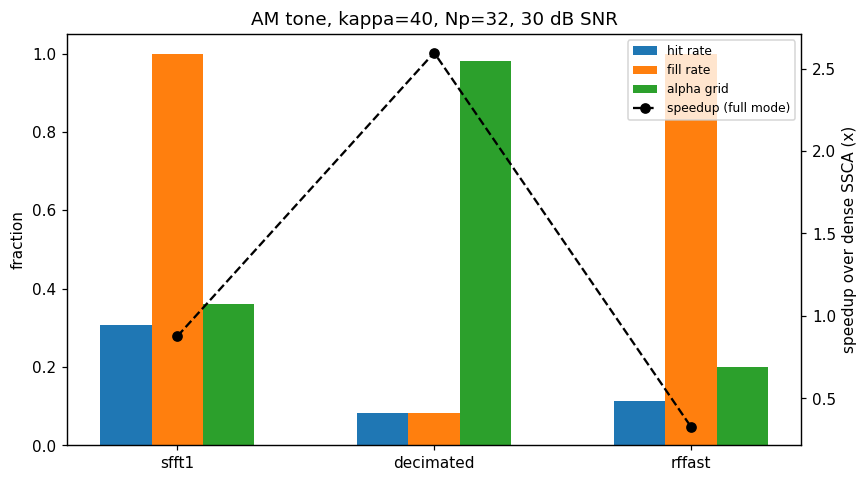

In [7]:
names, metrics = bc.comparison_table(result_am)
fig, ax1 = plt.subplots(figsize=(8,4.5))
width = 0.2
x = np.arange(len(names))
for i, m in enumerate(["hit rate", "fill rate", "alpha grid"]):
    ax1.bar(x + (i-1)*width, metrics[m], width, label=m)
ax1.set_xticks(x); ax1.set_xticklabels(names)
ax1.set_ylabel("fraction"); ax1.set_ylim(0, 1.05)
ax1.set_title("AM tone, kappa=40, Np=32, 30 dB SNR")
ax2 = ax1.twinx()
ax2.plot(x, metrics["speedup (x, right axis)"], "ko--", label="speedup (full mode)")
ax2.set_ylabel("speedup over dense SSCA (x)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

`decimated` comes into its own here: 98% `alpha grid`, exactly matching
its docstring's claim to this being its "home turf". `rffast` still shows
the same "100% fill, mediocre accuracy" signature as on BPSK, which says
something useful: the miscalibration is a property of **the default
threshold heuristic**, not of the signal type. §5 already showed the
underlying decoder *can* hit near-perfect recovery once it has a properly
calibrated noise level -- the open engineering item is propagating a
*correct* noise estimate through the channelizer/CDP pipeline (the noise
seen by the sparse-FFT stage is the CDP's noise, not the raw signal's,
and translating between the two needs channelizer-gain bookkeeping this
notebook doesn't attempt to solve). Until then, `rffast`'s default
`noise_var=None` fallback should be treated as a rough starting point, not
a tuned detector -- exactly the caveat flagged when it was first built.

One more honest note: at these modest sizes ($N\sim 2^{16}$--$2^{17}$),
`rffast`'s "full" speedup is sometimes **below 1x** -- slower than the
dense SSCA baseline. This reference implementation is pure Python/NumPy
with a fair amount of per-stage, per-iteration Python-level looping in the
peeling decoder; `sfft1`/`decimated` amortize their own Python overhead
better at this scale. The paper's own 30-90x speedups are measured against
FFTW at $N\!\ge\!2^{20}$, where the dense reference gets proportionally
much more expensive and $O(N)$-vs-$O(\kappa\,\mathrm{polylog}\,n)$
asymptotics actually take over -- worth re-running this notebook at larger
$N$ if wall-clock comparisons matter to you.

## 8. Is R-FFAST's default calibration actually fixable?

Two distinct problems were tangled together in §6/§7's "100% fill rate,
mediocre accuracy" result, and they call for different fixes.

**Problem A -- the threshold estimation itself was crude.** The original
fallback (no known noise variance) computed one percentile of each stage's
bin energies *once*, before any peeling -- at that point every occupied
bin's energy still includes its real signal, biasing the floor estimate
upward on exactly the bins you most want to separate from noise. Fix:
**re-estimate the floor every iteration**, from the *current* (partially
peeled) residual, using the stage's own **median** energy as the
reference rather than a low percentile, and **tighten the residual-based
singleton-acceptance margin** (`resid_slack`) so a bin has to fit the
single-frequency model noticeably better than the noise floor to be
accepted, not just "not obviously worse". This costs nothing extra to
compute (the energies are already being computed every pass) and needs no
externally-supplied noise level.

**Problem B -- the front end's own aliasing loss.** Recall from §5:
subsampling by $P_s=n/f_s$ and rescaling by $P_s$ inflates noise variance
by $P_s\cdot n$. Critically, $f_s$ and $P_s$ are **reciprocal for a fixed
$n$** ($f_s\cdot P_s = n$, always) -- there is no threshold trick that
escapes this; the only way to cut the aliasing loss is to raise $f_s$,
which necessarily means reading more raw samples ($\propto\sum_s f_s$)
and running bigger per-stage FFTs. It's a real dial, not a bug, but it's
*architectural*, not a calibration fix.

Cell below: Problem A's fix, isolated (same signal, same $f$, only the
threshold logic changes) -- this is now `rffast.py`'s default.

In [8]:
result_bpsk_tuned = bc.run_comparison(
    kappa=50, Np=32, snr_db=10.0, seed=0,
    rffast_kwargs=dict(energy_percentile=50.0, resid_slack=0.05))
result_am_tuned = bc.run_amtone_comparison(
    kappa=40, Np=32, snr_db=30.0, seed=1,
    rffast_kwargs=dict(energy_percentile=50.0, resid_slack=0.05))

def rf_row(label, r):
    print(f"{label:34} hit={r.full_hit_rate:6.1%}  fill={r.fill_rate:6.1%}  "
          f"alpha_grid={(r.alpha_grid_hit_rate or 0):6.1%}  speedup={r.full_speedup:5.2f}x")

print("BPSK (kappa=50, 10 dB SNR):")
rf_row("  before (pct=20, slack=0.5)", result_bpsk.reports["rffast"])
rf_row("  after  (pct=50, slack=0.05)", result_bpsk_tuned.reports["rffast"])
print()
print("AM tone (kappa=40, 30 dB SNR):")
rf_row("  before (pct=20, slack=0.5)", result_am.reports["rffast"])
rf_row("  after  (pct=50, slack=0.05)", result_am_tuned.reports["rffast"])

BPSK (kappa=50, 10 dB SNR):
  before (pct=20, slack=0.5)       hit=  6.8%  fill=100.0%  alpha_grid=  7.6%  speedup= 0.85x
  after  (pct=50, slack=0.05)      hit=  5.3%  fill= 40.6%  alpha_grid= 14.3%  speedup= 1.54x

AM tone (kappa=40, 30 dB SNR):
  before (pct=20, slack=0.5)       hit= 11.2%  fill=100.0%  alpha_grid= 19.9%  speedup= 0.33x
  after  (pct=50, slack=0.05)      hit=  7.7%  fill= 64.5%  alpha_grid= 23.2%  speedup= 0.84x

A real, if partial, improvement: fill rate drops sharply on both scenarios
(the decoder stops reporting a confident-looking full $\kappa$ every
channel) and precision (`alpha_grid`) improves on BPSK -- and, as a side
effect, `full` mode gets noticeably *faster* too, since fewer accepted
candidates means less downstream matched-filter/peeling work. This is
exactly the shape of `decimated`'s own honest behaviour: lower recall, but
what it reports is more often right. It does **not** close the gap to
`decimated`'s 99% `alpha_grid` on BPSK -- that gap is Problem B (and the
deeper approximately-sparse-vs-exactly-sparse mismatch from §6), which a
threshold can't fix.

### Testing Problem B's fix: does raising $f_s$ actually help?

Holding $n$ **fixed** this time (unlike an earlier, flawed attempt during
this project that let $n$ float upward with $f_s$, which -- as the algebra
predicts -- makes the aliasing loss *worse*, not better), search the
*same* $n$'s own divisors for stage-bin counts near $c\kappa$ for growing
$c$, and see whether the aliasing loss (and the recovered accuracy) moves
the way the theory says it should.

In [9]:
N_fixed = result_bpsk.N_rffast   # 124950 -- hold this fixed for the whole sweep
x, dr = bc.bpsk_signal(N_fixed, 0.25, 31, 10.0, seed=0)

print(f"{'target c*kappa':>15} {'f':>18} {'worst-case P_s':>15} {'aliasing-loss (dB)':>19} "
      f"{'hit':>7} {'fill':>7} {'alpha_grid':>11} {'sparsity':>9} {'speedup':>8}")
for c in (1, 2):
    try:
        f = rffast.choose_stage_bins(N_fixed, c*50, d=3).tolist()
    except ValueError as e:
        print(f"  c={c}: {e}")
        continue
    P_worst = N_fixed // min(f)
    loss_db = 10*np.log10(P_worst * N_fixed)
    r = s3ca.check(x, 32, 50, backend="rffast", seed=0, f=f, per_cluster=3,
                   expected_data_rate=dr, alpha_tol_bins=2)
    agr = f"{r.alpha_grid_hit_rate:.1%}" if r.alpha_grid_hit_rate is not None else "n/a"
    print(f"{c:>15} {str(f):>18} {P_worst:>15} {loss_db:>19.1f} {r.full_hit_rate:>6.1%} "
          f"{r.fill_rate:>6.1%} {agr:>11} {r.full_sparsity_ratio:>8.1%} {r.full_speedup:>7.2f}x")

 target c*kappa                  f  worst-case P_s  aliasing-loss (dB)     hit    fill  alpha_grid  sparsity  speedup
              1       [49, 50, 51]            2550                85.0   5.3%  40.6%       14.3%     7.2%    3.88x
              2        [3, 85, 98]           41650                97.2   7.9%  47.7%       17.7%     8.8%    3.43x

This result is more interesting than a clean "backfire" story, and worth
being precise about. $N=124{,}950=2\cdot 3^2\cdot 5^2\cdot 7\cdot 17$ only
has 5 distinct prime factors, so at $c=2$ the greedy coprime search is
forced into a **lopsided** split, $f=[3, 85, 98]$: one tiny leftover
factor alongside two considerably larger ones. Judged by the crude
*worst-case* $P_s$ (set entirely by the "3"), the aliasing loss looks
worse (97.2 dB vs 85.0 dB) -- but the actual recovery metrics **mildly
improved**, not degraded. The reason: peeling only needs *some* stages to
seed real detections, and the two larger stages here ($f=85,98$, giving
$P_s\approx 1470, 1275$) individually have noticeably *less* aliasing loss
than any of the three balanced $f\approx 50$ stages did -- the one bad
stage doesn't erase that benefit, it just contributes fewer usable
detections of its own. A single worst-case-$P_s$ number is too coarse a
proxy for what a lopsided, multi-stage front end actually does; the
per-stage picture matters more than the summary statistic.

The takeaway that *does* generalize cleanly: **raising $f_s$ trades
samples read for aliasing-loss margin, stage by stage** ($f_s\cdot
P_s=n$ always, so every doubling of a given stage's $f_s$ roughly halves
that stage's $P_s$ and buys back about 3 dB), and how much of that trade
is available to you depends on how composite your chosen $N$ is -- a
richer factorization (many small, repeated prime factors, not "three
numbers near $\kappa$ multiplied together") gives more balanced, and
therefore more genuinely beneficial, choices of $f_s$ to pick from. If you
have freedom to choose your block length $N$, that's the free variable
most worth spending on this.

## 9. Conclusions: when to reach for which backend

| Backend | Best suited to | Weak point (as measured here) |
|---|---|---|
| `sfft1` | Approximately-sparse spectra (real comms signals, DSSS-BPSK); no constraint on $N$ | Randomized front end fragments COMPIDX's shared-sample trick unless every channel reuses one seed |
| `decimated` | Genuinely (near-)sparse spectra; deterministic front end is ideal for FPGA; high-precision/low-recall behaviour | Abstains heavily (low fill rate) on spread spectra like DSSS-BPSK |
| `rffast` | Genuinely sparse spectra *with either a known noise level or a properly composite $N$*; provably noise-robust in theory; zero naive/full COMPIDX gap by construction (fixed front end) | Needs $N$ with a specific factorization; aliasing/decimation loss scales with $P_s\!\cdot\!n$ and $f_s\cdot P_s=n$ is a hard per-stage constraint -- the fix is a more composite $N$ (giving more, better-balanced choices of $f_s$), not more delay chains alone |

The overarching lesson from building this: **the sparse-FFT engine and the
spectral sparsity model it assumes have to match the actual signal**, and
for `rffast` specifically, **the block length $N$'s own factorization is
part of the design space, not an afterthought** -- picking $N$ deliberately
composite is the one lever that buys back SNR margin without touching the
decoder at all. `sfft1`'s general "approximately sparse" guarantee remains
the safer default for real communication signals; `decimated` and
`rffast`'s harder exactly-sparse, singleton/multi-ton model pays off on
cleaner sparse spectra (and, for `decimated`, on FPGA-friendliness) but
needs a genuinely sparse signal, careful threshold calibration (§8's
median/re-estimated-per-iteration fix, now the default), and -- for
`rffast` -- enough compositeness in $N$ to avoid an unfavorable
$f_s$-vs-$P_s$ trade, to avoid either abstaining constantly or reporting
confident nonsense.

### References
- C. J. Li, R. Rademacher, D. Boland, C. T. Jin, C. M. Spooner, P. H. W.
  Leong, "S3CA: A Sparse Strip Spectral Correlation Analyzer," *IEEE
  Signal Processing Letters*, 2015.
- H. Hassanieh, P. Indyk, D. Katabi, E. Price, "Simple and Practical
  Algorithm for Sparse Fourier Transform," SODA 2012.
- S. Pawar, K. Ramchandran, "A robust sub-linear time R-FFAST algorithm
  for computing a sparse DFT," arXiv:1501.00320, 2015.
- S. Kay, "A fast and accurate single frequency estimator," *IEEE Trans.
  ASSP*, 1989.
- S.-H. Hsieh, C.-S. Lu, S.-C. Pei, "Compressive Sensing Matrix Design for
  Fast Encoding and Decoding via Sparse FFT," *IEEE Signal Processing
  Letters*, 2018 (the earlier discussion connecting S3CA's COMPIDX to
  compressive-sensing sensing-matrix design).